In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
adata = sc.read_h5ad('/lustre/groups/ml01/datasets/projects/20230301_Sander_SpatialPancreas_sara.jimenez/scrna/072424_npod_RNA_raw.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 276906 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.1', 'seurat_clusters', 'samples', 'sex', 'condition', 'RNA_snn_res.0.5', 'celltype_assignment1', 'SeuratClusters', 'celltype_assignment2', 'barcode', 'nPOD_barcode', 'CurrentObjLabels', 'nPOD_ID', 'technology', 'nCount_RAW_mtx', 'nFeature_RAW_mtx', 'conditionSubtype', 'CellTypes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    layers: 'counts'

In [5]:
adata.obs.condition.value_counts()

condition
Control    113215
Aab         84621
T1D         79070
Name: count, dtype: int64

In [6]:
adata_control = adata[adata.obs.condition == 'Control']

In [7]:
adata_control

View of AnnData object with n_obs × n_vars = 113215 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.1', 'seurat_clusters', 'samples', 'sex', 'condition', 'RNA_snn_res.0.5', 'celltype_assignment1', 'SeuratClusters', 'celltype_assignment2', 'barcode', 'nPOD_barcode', 'CurrentObjLabels', 'nPOD_ID', 'technology', 'nCount_RAW_mtx', 'nFeature_RAW_mtx', 'conditionSubtype', 'CellTypes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    layers: 'counts'

/home/aih/shrey.parikh/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


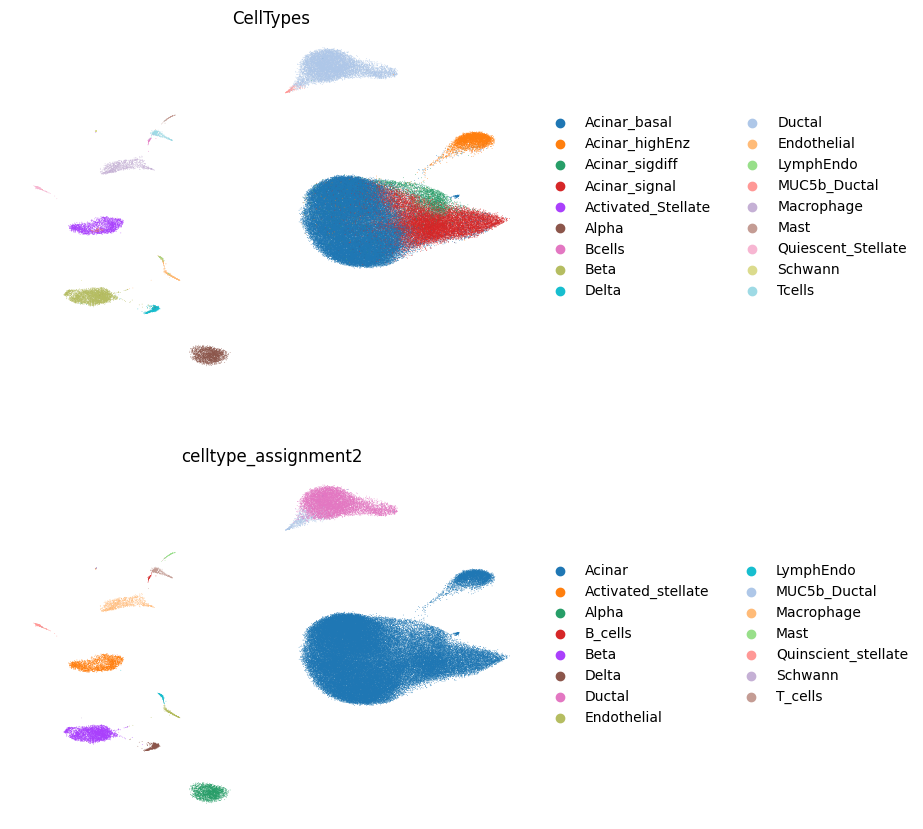

In [8]:
sc.pl.umap(adata_control, color=['CellTypes', 'celltype_assignment2'], frameon=False, ncols=1)

In [9]:
adata_control.obs.technology.value_counts()

technology
snRNA       99885
multiome    13330
Name: count, dtype: int64

In [10]:
subset = sc.pp.subsample(adata_control, fraction=0.01, copy=True)
X = subset.layers['counts'].toarray() if hasattr(subset.X, "toarray") else subset.X

print(f"Min: {X.min()}, Max: {X.max()}, Mean: {X.mean()}")

# Check if all values are integers (raw count hint)
is_integer = np.allclose(X, X.astype(int))
print(f"All values are integers: {is_integer}")
print('-'*50)

Min: 0.0, Max: 2414.0, Mean: 0.06421933962104764
All values are integers: True
--------------------------------------------------


In [11]:
adata_control.layers['normcounts'] = adata_control.X.copy()
adata_control.X = adata_control.layers['counts']

In [12]:
adata_control.obs['Dataset'] = 'Jimenez'

In [13]:
adata_control.obs.head()

,nCount_RNA,nFeature_RNA,percent.mt,RNA_snn_res.1,seurat_clusters,samples,sex,condition,RNA_snn_res.0.5,celltype_assignment1,SeuratClusters,celltype_assignment2,barcode,nPOD_barcode,CurrentObjLabels,nPOD_ID,technology,nCount_RAW_mtx,nFeature_RAW_mtx,conditionSubtype,CellTypes,Dataset
MM_356_AAACCCATCCATCCGT-1,3725.0,1924,0.0,3,5,MM_356,M,Control,5,Acinar,5,Acinar,AAACCCATCCATCCGT,MM_356_AAACCCATCCATCCGT,Acinar1_2_6,6339,snRNA,4370.0,2278,Control,Acinar_basal,Jimenez
MM_356_AAACGAATCGAAATCC-1,3510.0,1724,0.0,3,1,MM_356,M,Control,1,Acinar,1,Acinar,AAACGAATCGAAATCC,MM_356_AAACGAATCGAAATCC,Acinar1_2_6,6339,snRNA,4112.0,2062,Control,Acinar_basal,Jimenez
MM_356_AAACGAATCGCCTAGG-1,3033.0,1591,0.0,6,2,MM_356,M,Control,2,Acinar,2,Acinar,AAACGAATCGCCTAGG,MM_356_AAACGAATCGCCTAGG,Acinar_3,6339,snRNA,3644.0,1899,Control,Acinar_signal,Jimenez
MM_356_AAACGCTAGGCTAACG-1,4656.0,1923,0.0,1,5,MM_356,M,Control,5,Acinar,5,Acinar,AAACGCTAGGCTAACG,MM_356_AAACGCTAGGCTAACG,Acinar_3,6339,snRNA,5513.0,2373,Control,Acinar_signal,Jimenez
MM_356_AAACGCTAGTCATAGA-1,3757.0,1925,0.0,9,4,MM_356,M,Control,4,Ductal,4_1,Ductal,AAACGCTAGTCATAGA,MM_356_AAACGCTAGTCATAGA,Ductal,6339,snRNA,4308.0,2251,Control,Ductal,Jimenez


# QC

In [14]:
adata_control.var["mito"] = adata_control.var_names.str.startswith("MT-")

In [15]:
adata_control.var.head()

,vst.mean,vst.variance,vst.variance.expected,vst.variance.standardized,vst.variable,mito
MIR1302-2HG,0.000018,0.000018,0.000018,0.981577,False,False
FAM138A,0.000000,0.000000,0.000000,0.000000,False,False
OR4F5,0.000004,0.000004,0.000004,0.998491,False,False
AL627309.1,0.006013,0.006266,0.007674,0.816508,False,False
AL627309.3,0.000293,0.000292,0.000317,0.922415,False,False


In [16]:
adata_control.var.mito.value_counts()

mito
False    36588
True        13
Name: count, dtype: int64

In [17]:
sc.pp.calculate_qc_metrics(adata_control, inplace=True, qc_vars=["mito"])

In [18]:
adata_control.obs.head()

,nCount_RNA,nFeature_RNA,percent.mt,RNA_snn_res.1,seurat_clusters,samples,sex,condition,RNA_snn_res.0.5,celltype_assignment1,SeuratClusters,celltype_assignment2,barcode,nPOD_barcode,CurrentObjLabels,nPOD_ID,technology,nCount_RAW_mtx,nFeature_RAW_mtx,conditionSubtype,CellTypes,Dataset,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mito,log1p_total_counts_mito,pct_counts_mito
MM_356_AAACCCATCCATCCGT-1,3725.0,1924,0.0,3,5,MM_356,M,Control,5,Acinar,5,Acinar,AAACCCATCCATCCGT,MM_356_AAACCCATCCATCCGT,Acinar1_2_6,6339,snRNA,4370.0,2278,Control,Acinar_basal,Jimenez,1924,7.562681,3725.0,8.223091,27.167785,33.583893,42.255034,59.221477,0.0,0.0,0.0
MM_356_AAACGAATCGAAATCC-1,3510.0,1724,0.0,3,1,MM_356,M,Control,1,Acinar,1,Acinar,AAACGAATCGAAATCC,MM_356_AAACGAATCGAAATCC,Acinar1_2_6,6339,snRNA,4112.0,2062,Control,Acinar_basal,Jimenez,1724,7.452982,3510.0,8.163656,28.148148,35.099715,44.700855,63.247863,0.0,0.0,0.0
MM_356_AAACGAATCGCCTAGG-1,3033.0,1591,0.0,6,2,MM_356,M,Control,2,Acinar,2,Acinar,AAACGAATCGCCTAGG,MM_356_AAACGAATCGCCTAGG,Acinar_3,6339,snRNA,3644.0,1899,Control,Acinar_signal,Jimenez,1591,7.372746,3033.0,8.017637,20.573689,28.882295,39.927465,61.819980,0.0,0.0,0.0
MM_356_AAACGCTAGGCTAACG-1,4656.0,1923,0.0,1,5,MM_356,M,Control,5,Acinar,5,Acinar,AAACGCTAGGCTAACG,MM_356_AAACGCTAGGCTAACG,Acinar_3,6339,snRNA,5513.0,2373,Control,Acinar_signal,Jimenez,1923,7.562162,4656.0,8.446127,34.729381,40.850515,49.012027,64.497423,0.0,0.0,0.0
MM_356_AAACGCTAGTCATAGA-1,3757.0,1925,0.0,9,4,MM_356,M,Control,4,Ductal,4_1,Ductal,AAACGCTAGTCATAGA,MM_356_AAACGCTAGTCATAGA,Ductal,6339,snRNA,4308.0,2251,Control,Ductal,Jimenez,1925,7.563201,3757.0,8.231642,21.959010,28.826191,38.514772,57.492680,0.0,0.0,0.0


In [19]:
from scipy.stats import median_abs_deviation
def is_outlier(data, nmads=5):
    median = np.median(data)
    mad = median_abs_deviation(data)
    return (data < median - nmads * mad) | (data > median + nmads * mad)

In [20]:
adata_control.obs['outlier'] = False
for cell in adata_control.obs.celltype_assignment2.unique():
    print(f'Filtering for {cell}')
    cell_mask = (adata_control.obs['celltype_assignment2'] == cell)
    total_outliers = pd.Series(False, index=adata_control.obs.index)
    outlier_total_counts = is_outlier(adata_control.obs.loc[cell_mask, 'log1p_total_counts'], 4)
    outlier_n_genes = is_outlier(adata_control.obs.loc[cell_mask, 'log1p_n_genes_by_counts'], 4)
    outlier_mito = is_outlier(adata_control.obs.loc[cell_mask, 'pct_counts_mito'], 4)
    combined_outlier = outlier_total_counts | outlier_n_genes | outlier_mito
    adata_control.obs.loc[cell_mask, 'outlier'] |= combined_outlier
print('-' *50)

Filtering for Acinar
Filtering for Ductal
Filtering for Beta
Filtering for Alpha
Filtering for Activated_stellate
Filtering for Delta
Filtering for Quinscient_stellate
Filtering for MUC5b_Ductal
Filtering for Macrophage
Filtering for Endothelial
Filtering for LymphEndo
Filtering for T_cells
Filtering for Mast
Filtering for Schwann
Filtering for B_cells
--------------------------------------------------


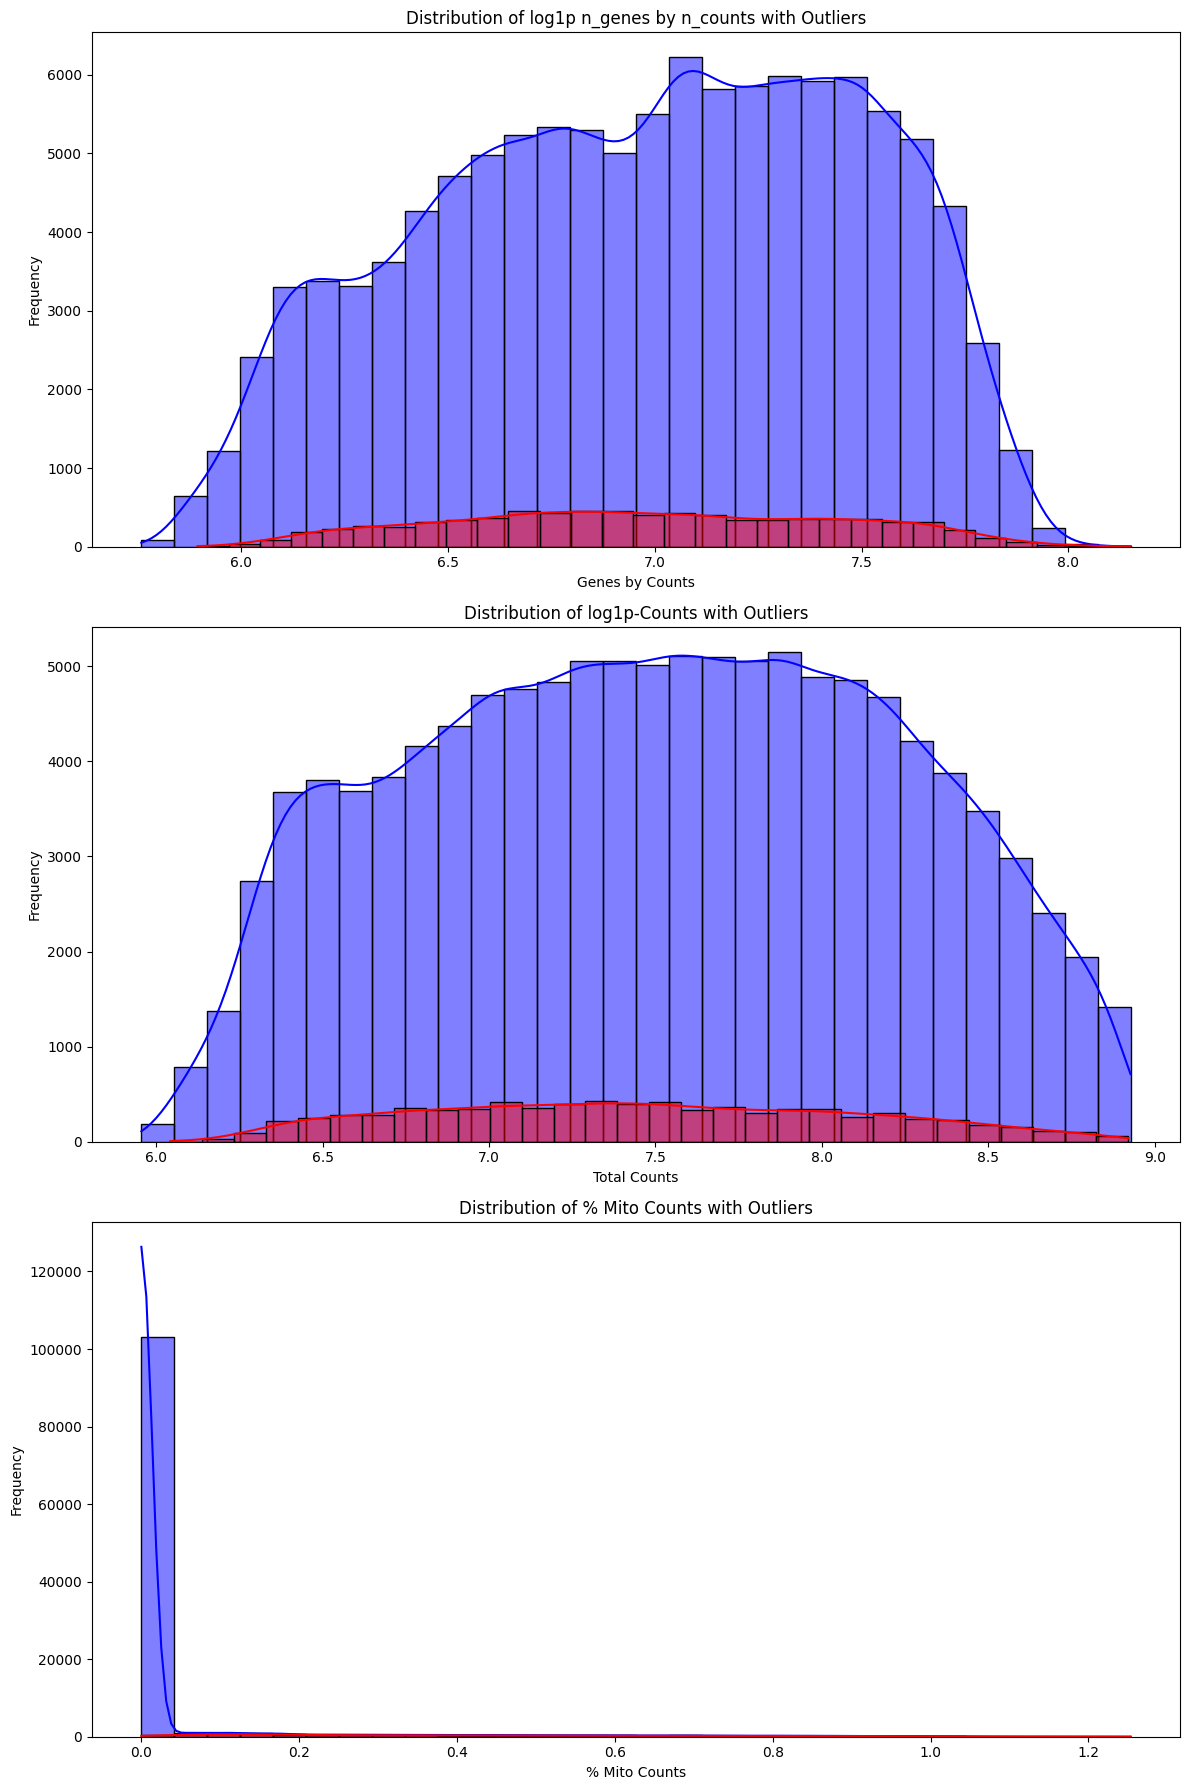

In [21]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1,figsize=(12, 18))
# plt.figure()
sns.histplot(adata_control.obs['log1p_n_genes_by_counts'], bins=30, kde=True, color="blue", label='Data', ax=ax1)
sns.histplot(adata_control.obs.loc[adata_control.obs['outlier'], 'log1p_n_genes_by_counts'], bins=30, kde=True, color="red", label='Outliers', ax=ax1)
ax1.set_xlabel('Genes by Counts')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of log1p n_genes by n_counts with Outliers')

sns.histplot(adata_control.obs['log1p_total_counts'], bins=30, kde=True, color="blue", label='Data', ax=ax2)
sns.histplot(adata_control.obs.loc[adata_control.obs['outlier'], 'log1p_total_counts'], bins=30, kde=True, color="red", label='Outliers', ax=ax2)
ax2.set_xlabel('Total Counts')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of log1p-Counts with Outliers')

sns.histplot(adata_control.obs['pct_counts_mito'], bins=30, kde=True, color="blue", label='Data', ax=ax3)
sns.histplot(adata_control.obs.loc[adata_control.obs['outlier'], 'pct_counts_mito'], bins=30, kde=True, color="red", label='Outliers', ax=ax3)
ax3.set_xlabel('% Mito Counts')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of % Mito Counts with Outliers')

plt.tight_layout()
plt.show()

In [22]:
adata_control.obs.outlier.value_counts()

outlier
False    105309
True       7906
Name: count, dtype: int64

In [23]:
adata_control.obs.groupby(['celltype_assignment2', 'outlier']).size().unstack()

/tmp/ipykernel_329549/551859629.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_control.obs.groupby(['celltype_assignment2', 'outlier']).size().unstack()


outlier,False,True
celltype_assignment2,,
Acinar,87419,5033
Activated_stellate,1940,216
Alpha,1606,500
B_cells,42,4
Beta,2229,1091
Delta,336,328
Ductal,9099,448
Endothelial,355,17
LymphEndo,175,0


In [62]:
adata_control_filtered = adata_control[adata_control.obs.outlier == False]

In [63]:
adata_control_filtered = adata_control_filtered[adata_control_filtered.obs.technology == 'snRNA']

In [64]:
adata_control_filtered.obs.rename(columns={'CellTypes': 'Author_Annotation', 'celltype_assignment2': 'Cell_Type_Harmonized'}, inplace=True)

In [65]:
adata_control_filtered.obs.Cell_Type_Harmonized.value_counts()

Cell_Type_Harmonized
Acinar                 76721
Ductal                  8587
Beta                    2040
Activated_stellate      1592
Alpha                   1459
Macrophage               668
MUC5b_Ductal             592
Delta                    326
Endothelial              272
T_cells                  254
Quinscient_stellate      174
LymphEndo                128
Mast                      53
B_cells                   41
Schwann                   28
Name: count, dtype: int64

In [66]:
harmonization_dict = {'Acinar': 'Acinar Cell',
 'Ductal': 'Ductal Cell',
 'Alpha':'Alpha Cell',
 'Beta': 'Beta Cell',
 'Activated_stellate': 'Stellate Cell',
 'Delta': 'Delta Cell',
 'Quinscient_stellate': 'Stellate Cell',
 'MUC5b_Ductal': 'Ductal Cell',
 'Macrophage': 'Macrophage',
 'Endothelial': 'Endothelial Cell',
 'LymphEndo': 'LymphEndo',
 'T_cells': 'T Cell',
 'Mast': 'Mast Cell',
 'Schwann': 'Schwann Cell',
 'B_cells': 'B Cell'}


In [67]:
adata_control_filtered.obs.Cell_Type_Harmonized = adata_control_filtered.obs.Cell_Type_Harmonized.map(harmonization_dict)

/home/aih/shrey.parikh/miniconda3/envs/scanpy/lib/python3.10/site-packages/pandas/core/generic.py:6329: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  self[name] = value


In [68]:
adata_control_filtered.obs.Cell_Type_Harmonized.value_counts()

Cell_Type_Harmonized
Acinar Cell         76721
Ductal Cell          9179
Beta Cell            2040
Stellate Cell        1766
Alpha Cell           1459
Macrophage            668
Delta Cell            326
Endothelial Cell      272
T Cell                254
LymphEndo             128
Mast Cell              53
B Cell                 41
Schwann Cell           28
Name: count, dtype: int64

In [69]:
adata_control_filtered.obs.groupby(['nPOD_ID', 'samples']).size().unstack()

/tmp/ipykernel_329549/3997399177.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_control_filtered.obs.groupby(['nPOD_ID', 'samples']).size().unstack()


samples,MM_356,MM_359,MM_360,MM_381,MM_382,MM_400,MM_404,MM_407,MM_426,MM_554,MM_558,MM_561
nPOD_ID,,,,,,,,,,,,
6229,0,0,0,0,0,0,7252,0,0,0,0,0
6234,0,0,0,0,0,7701,0,0,0,0,0,0
6278,0,0,0,0,0,0,0,0,7372,0,0,0
6282,0,0,3721,0,0,0,0,0,0,9467,0,0
6339,2631,0,0,0,0,0,0,0,0,0,0,0
6366,0,0,0,0,0,0,0,0,0,0,0,7052
6375,0,6707,0,0,0,0,0,0,0,0,0,0
6393,0,0,0,0,0,0,0,0,0,0,7527,0
6401,0,0,0,0,0,0,0,6776,0,0,0,0


In [70]:
adata_control_filtered.obs['conditionSubtype'].value_counts()

conditionSubtype
Control    92935
Name: count, dtype: int64

In [71]:
adata_control_filtered

AnnData object with n_obs × n_vars = 92935 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.1', 'seurat_clusters', 'samples', 'sex', 'condition', 'RNA_snn_res.0.5', 'celltype_assignment1', 'SeuratClusters', 'Cell_Type_Harmonized', 'barcode', 'nPOD_barcode', 'CurrentObjLabels', 'nPOD_ID', 'technology', 'nCount_RAW_mtx', 'nFeature_RAW_mtx', 'conditionSubtype', 'Author_Annotation', 'Dataset', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'outlier'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'CellTypes_colors', 'celltype_assignment2_colors'
   

In [72]:
adata_control_filtered.obs = adata_control_filtered.obs[['samples', 'sex', 'condition','Cell_Type_Harmonized', 'barcode', 'nPOD_barcode','nPOD_ID', 'technology', 'Author_Annotation', 'Dataset', 'n_genes_by_counts', 
                                                         'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 
                                                         'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 
                                                         'pct_counts_mito', 'outlier']]

In [73]:
adata_control_filtered.obs.head()

,samples,sex,condition,Cell_Type_Harmonized,barcode,nPOD_barcode,nPOD_ID,technology,Author_Annotation,Dataset,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mito,log1p_total_counts_mito,pct_counts_mito,outlier
MM_356_AAACCCATCCATCCGT-1,MM_356,M,Control,Acinar Cell,AAACCCATCCATCCGT,MM_356_AAACCCATCCATCCGT,6339,snRNA,Acinar_basal,Jimenez,1924,7.562681,3725.0,8.223091,27.167785,33.583893,42.255034,59.221477,0.0,0.0,0.0,False
MM_356_AAACGAATCGAAATCC-1,MM_356,M,Control,Acinar Cell,AAACGAATCGAAATCC,MM_356_AAACGAATCGAAATCC,6339,snRNA,Acinar_basal,Jimenez,1724,7.452982,3510.0,8.163656,28.148148,35.099715,44.700855,63.247863,0.0,0.0,0.0,False
MM_356_AAACGAATCGCCTAGG-1,MM_356,M,Control,Acinar Cell,AAACGAATCGCCTAGG,MM_356_AAACGAATCGCCTAGG,6339,snRNA,Acinar_signal,Jimenez,1591,7.372746,3033.0,8.017637,20.573689,28.882295,39.927465,61.819980,0.0,0.0,0.0,False
MM_356_AAACGCTAGGCTAACG-1,MM_356,M,Control,Acinar Cell,AAACGCTAGGCTAACG,MM_356_AAACGCTAGGCTAACG,6339,snRNA,Acinar_signal,Jimenez,1923,7.562162,4656.0,8.446127,34.729381,40.850515,49.012027,64.497423,0.0,0.0,0.0,False
MM_356_AAACGCTAGTCATAGA-1,MM_356,M,Control,Ductal Cell,AAACGCTAGTCATAGA,MM_356_AAACGCTAGTCATAGA,6339,snRNA,Ductal,Jimenez,1925,7.563201,3757.0,8.231642,21.959010,28.826191,38.514772,57.492680,0.0,0.0,0.0,False


In [80]:
adata_control_filtered.X = adata_control_filtered.layers['normcounts'].copy()

In [37]:
adata_core = sc.read_h5ad('scanvi_intersecting_3000_with_umap.h5ad')

In [39]:
adata_core.obs.head()

,Author_Annotation,Cell_Annotation_Merged,Cell_Type_Harmonized,Dataset,GSE183568_Annotation,GSE198623_Annotation,GSE84133_Annotation,HPAP_Annotation,ID,Manual_Annotation,alignment_software,assay_ontology_term_id,barcode,batch_covar_split,batch_covar_split_donor_id,batch_covariate,cell_enrichment,celltype_all,charite_snRNA_Annotation,donor_id,doublet_score,espace_Annotation,gene_annotation_version,info_batch_covariate_split,institute,library_id,library_preparation_batch,library_sequencing_run,log1p_n_genes_by_counts,log1p_total_counts,log1p_total_counts_mito,log1p_total_counts_ribo,manner_of_death,n_genes,n_genes_by_counts,organism_ontology_term_id,outlier,outlier_mito,outlier_n_genes,outlier_total_counts,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,pct_counts_in_top_50_genes,pct_counts_mito,pct_counts_ribo,predicted_doublet,reference_genome,sample_collection_method,sample_id,sample_source,sampled_site_condition,sex_ontology_term_id,suspension_type,tissue_type,total_counts,total_counts_mito,total_counts_ribo
barcode_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AAAACTAAGGCA_GSM2700343_GeneFull_filtered,NaN,Pancreatic Polypeptide Cell,Pancreatic Polypeptide Cell,GSE101207_remapped,NaN,NaN,NaN,NaN,GSM2700343_GeneFull_filtered,Pancreatic Polypeptide Cell,STAR,EFO:0008722,AAAACTAAGGCA_GSM2700343_GeneFull_filtered,GSE101207_remapped,NaN,Diabetic_donor_1,NaN,Pancreatic Polypeptide Cell,NaN,Diabetic_donor_1,0.092838,NaN,NaN,GSE101207_remapped_split_donor_id_Diabetic_don...,NaN,SRX2996339,0,SRR5818093,6.095825,6.447306,3.496508,3.761200,unknown,439,443,NCBITaxon:9606,False,False,False,False,45.555556,61.428571,100.000000,37.619048,5.079365,6.666667,False,GRCh37,surgical resection,SAMN07343858,organ donor,diseased,PATO:0000384,cell,tissue,630.0,32.0,42.0
AAAAGGAACCAT_GSM2700343_GeneFull_filtered,NaN,Alpha Cell,Alpha Cell,GSE101207_remapped,NaN,NaN,NaN,NaN,GSM2700343_GeneFull_filtered,Alpha Cell,STAR,EFO:0008722,AAAAGGAACCAT_GSM2700343_GeneFull_filtered,GSE101207_remapped,NaN,Diabetic_donor_1,NaN,Alpha Cell,NaN,Diabetic_donor_1,0.023464,NaN,NaN,GSE101207_remapped_split_donor_id_Diabetic_don...,NaN,SRX2996339,0,SRR5818093,5.942799,6.366470,2.197225,3.931826,unknown,377,380,NCBITaxon:9606,False,False,False,False,51.807229,69.018933,100.000000,43.201377,1.376936,8.605852,False,GRCh37,surgical resection,SAMN07343858,organ donor,diseased,PATO:0000384,cell,tissue,581.0,8.0,50.0
AAACCCTAACAT_GSM2700343_GeneFull_filtered,NaN,Beta Cell,Beta Cell,GSE101207_remapped,NaN,NaN,NaN,NaN,GSM2700343_GeneFull_filtered,Beta Cell,STAR,EFO:0008722,AAACCCTAACAT_GSM2700343_GeneFull_filtered,GSE101207_remapped,NaN,Diabetic_donor_1,NaN,Beta Cell,NaN,Diabetic_donor_1,0.044025,NaN,NaN,GSE101207_remapped_split_donor_id_Diabetic_don...,NaN,SRX2996339,0,SRR5818093,6.590301,6.980076,3.135494,4.584967,unknown,721,727,NCBITaxon:9606,False,False,False,False,38.826816,50.931099,78.864060,29.050279,2.048417,9.031657,False,GRCh37,surgical resection,SAMN07343858,organ donor,diseased,PATO:0000384,cell,tissue,1074.0,22.0,97.0
AAACGACGTTTA_GSM2700343_GeneFull_filtered,NaN,Alpha Cell,Alpha Cell,GSE101207_remapped,NaN,NaN,NaN,NaN,GSM2700343_GeneFull_filtered,Alpha Cell,STAR,EFO:0008722,AAACGACGTTTA_GSM2700343_GeneFull_filtered,GSE101207_remapped,NaN,Diabetic_donor_1,NaN,Alpha Cell,NaN,Diabetic_donor_1,0.053381,NaN,NaN,GSE101207_remapped_split_donor_id_Diabetic_don...,NaN,SRX2996339,0,SRR5818093,6.391917,6.844815,3.295837,4.110874,unknown,593,596,NCBITaxon:9606,False,False,False,False,47.121535,57.782516,89.765458,39.232409,2.771855,6.396588,False,GRCh37,surgical resection,SAMN07343858,organ donor,diseased,PATO:0000384,cell,tissue,938.0,26.0,60.0
AAAGCCTAAACA_GSM2700343_GeneFull_filtered,NaN,Ductal Cell,Ductal Cell,GSE101207_remapped,NaN,NaN,NaN,NaN,GSM2700343_GeneFull_filtered,Ductal Cell,STAR,EFO:0008722,AAAGCCTAAACA_GSM2700343_GeneFull_filtered,GSE101207_remapped,NaN,Diabetic_donor_1,NaN,Ductal Cell,NaN,Diabetic_donor_1,0.065

In [81]:
adata_core_all = sc.concat([adata_core, adata_control_filtered], join='outer')

In [76]:
adata_core_all

AnnData object with n_obs × n_vars = 1009893 × 49084
    obs: 'Author_Annotation', 'Cell_Annotation_Merged', 'Cell_Type_Harmonized', 'Dataset', 'GSE183568_Annotation', 'GSE198623_Annotation', 'GSE84133_Annotation', 'HPAP_Annotation', 'ID', 'Manual_Annotation', 'alignment_software', 'assay_ontology_term_id', 'barcode', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'cell_enrichment', 'celltype_all', 'charite_snRNA_Annotation', 'donor_id', 'doublet_score', 'espace_Annotation', 'gene_annotation_version', 'info_batch_covariate_split', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'manner_of_death', 'n_genes', 'n_genes_by_counts', 'organism_ontology_term_id', 'outlier', 'outlier_mito', 'outlier_n_genes', 'outlier_total_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'pct_counts_

In [82]:
for dataset in adata_core_all.obs.Dataset.unique():
    print(f'{dataset}')
    adata_temp = adata_core_all[adata_core_all.obs.Dataset == dataset]
    subset = sc.pp.subsample(adata_temp, fraction=0.01, copy=True)
    X = subset.X.toarray() if hasattr(subset.X, "toarray") else subset.X
    
    print(f"Min: {X.min()}, Max: {X.max()}, Mean: {X.mean()}")
    
    # Check if all values are integers (raw count hint)
    is_integer = np.allclose(X, X.astype(int))
    print(f"All values are integers: {is_integer}")
    print('-'*50)

GSE101207_remapped
Min: 0.0, Max: 7.511309325930484, Mean: 0.029697659907509312
All values are integers: False
--------------------------------------------------
GSE198623
Min: 0.0, Max: 8.081893672121993, Mean: 0.03027463498768203
All values are integers: False
--------------------------------------------------
GSE84133_remapped
Min: 0.0, Max: 4.740715677984315, Mean: 0.052236539395439215
All values are integers: False
--------------------------------------------------
GSE183568
Min: 0.0, Max: 8.043056672236382, Mean: 0.029856363794912334
All values are integers: False
--------------------------------------------------
Karakose
Min: 0.0, Max: 8.402129727776146, Mean: 0.032766998039675935
All values are integers: False
--------------------------------------------------
Tabula_Sapiens
Min: 0.0, Max: 6.538027713747133, Mean: 0.03887459440153942
All values are integers: False
--------------------------------------------------
GSE150724
Min: 0.0, Max: 7.6861851121499845, Mean: 0.0336300305

In [83]:
for dataset in adata_core_all.obs.Dataset.unique():
    print(f'{dataset}')
    adata_temp = adata_core_all[adata_core_all.obs.Dataset == dataset]
    subset = sc.pp.subsample(adata_temp, fraction=0.01, copy=True)
    X = subset.layers['counts'].toarray() if hasattr(subset.X, "toarray") else subset.X
    
    print(f"Min: {X.min()}, Max: {X.max()}, Mean: {X.mean()}")
    
    # Check if all values are integers (raw count hint)
    is_integer = np.allclose(X, X.astype(int))
    print(f"All values are integers: {is_integer}")
    print('-'*50)

GSE101207_remapped
Min: 0.0, Max: 974.0, Mean: 0.051057403721743846
All values are integers: True
--------------------------------------------------
GSE198623
Min: 0.0, Max: 22631.0, Mean: 0.29172486647998336
All values are integers: True
--------------------------------------------------
GSE84133_remapped
Min: 0.0, Max: 121.0, Mean: 0.1777466120504106
All values are integers: True
--------------------------------------------------
GSE183568
Min: 0.0, Max: 8108.0, Mean: 0.13363099898000858
All values are integers: True
--------------------------------------------------
Karakose
Min: 0.0, Max: 46173.0, Mean: 0.27639854192294905
All values are integers: True
--------------------------------------------------
Tabula_Sapiens
Min: 0.0, Max: 31791.0, Mean: 0.5054146509508746
All values are integers: True
--------------------------------------------------
GSE150724
Min: 0.0, Max: 18705.0, Mean: 0.22831723325163142
All values are integers: True
-------------------------------------------------

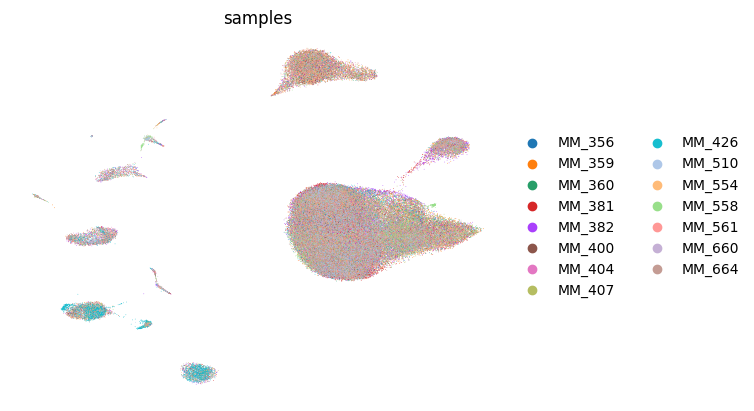

In [84]:
sc.pl.umap(adata_control, color=['samples'], frameon=False, ncols=1)

In [ ]:
- heterogeneity in the data, plot without harmony
- decide batch covariate
- feature selection based on new batch

In [ ]:
- why did we split espace by ID
- new dataset incorporation
- metadata in progress

# how to split the dataset

In [86]:
sc.pp.pca(adata_control_filtered, layer='normcounts')

In [87]:
sc.pp.neighbors(adata_control_filtered)
adata_control_filtered.obsm['X_umap_harmony'] = adata_control_filtered.obsm['X_umap'].copy()

/home/aih/shrey.parikh/miniconda3/envs/scanpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [88]:
sc.tl.umap(adata_control_filtered)

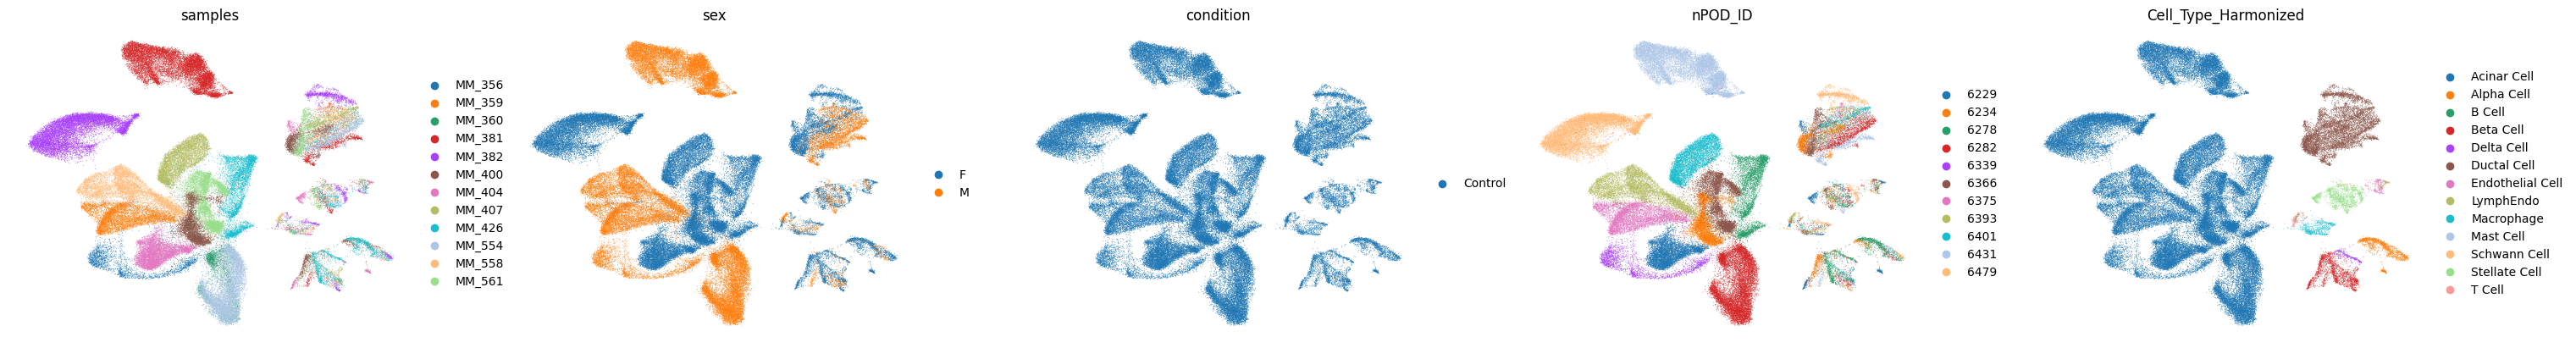

In [93]:
sc.pl.umap(adata_control_filtered, color=['samples', 'sex', 'condition', 'nPOD_ID', 'Cell_Type_Harmonized'], frameon=False, ncols=5)

In [90]:
adata_control_filtered

AnnData object with n_obs × n_vars = 92935 × 36601
    obs: 'samples', 'sex', 'condition', 'Cell_Type_Harmonized', 'barcode', 'nPOD_barcode', 'nPOD_ID', 'technology', 'Author_Annotation', 'Dataset', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'outlier'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'CellTypes_colors', 'celltype_assignment2_colors', 'pca', 'neighbors', 'umap', 'samples_colors'
    obsm: 'X_harmony', 'X_pca', 'X_umap', 'X_umap_harmony'
    varm: 'PCs'
    layers: 'counts', 'normcounts'
    obsp: 'distances', 'connectivities'

# add ID as batch for the new dataset

In [98]:
adata_core_all.obs.groupby('Dataset')['batch_covar_split'].apply(lambda x: x.isna().sum())

Dataset
GSE101207_remapped                  0
GSE114297_remapped                  0
GSE150724                           0
GSE183568                           0
GSE198623                           0
GSE84133_remapped                   0
HPAP                                0
Jimenez                         92935
Karakose                            0
Tabula_Sapiens                      0
charite_snRNA                       0
espace_scRNA_cultured_islets        0
espace_snRNA_adult_whole            0
espace_snRNA_frozen_islets          0
Name: batch_covar_split, dtype: int64

In [100]:
adata_core_all.obs['samples'].unique().tolist()

[nan,
 'MM_356',
 'MM_359',
 'MM_360',
 'MM_381',
 'MM_382',
 'MM_404',
 'MM_407',
 'MM_400',
 'MM_426',
 'MM_554',
 'MM_558',
 'MM_561']

In [102]:
adata_core_all.obs['batch_covar_split'] = (
    adata_core_all.obs['batch_covar_split']
    .astype(str)
    .where(~adata_core_all.obs['batch_covar_split'].isna(), adata_core_all.obs['samples'].astype(str))
)

In [103]:
adata_core_all.obs.groupby('Dataset')['batch_covar_split'].apply(lambda x: x.isna().sum())

Dataset
GSE101207_remapped              0
GSE114297_remapped              0
GSE150724                       0
GSE183568                       0
GSE198623                       0
GSE84133_remapped               0
HPAP                            0
Jimenez                         0
Karakose                        0
Tabula_Sapiens                  0
charite_snRNA                   0
espace_scRNA_cultured_islets    0
espace_snRNA_adult_whole        0
espace_snRNA_frozen_islets      0
Name: batch_covar_split, dtype: int64

In [107]:
adata_core_all.write('2025_06_23_adata_new_dataset.h5ad')